# Getting Started: QPE for H2

This notebook runs a minimal **Quantum Phase Estimation (QPE)** workflow for
the hydrogen molecule **H2**.

Goals:

- build the shared molecular Hamiltonian
- run a small QPE example
- inspect the returned phase information
- compare the estimated energy with the exact ground-state reference

This is the smallest end-to-end QPE workflow in the repository.

In [ ]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt

from common.hamiltonian import build_hamiltonian, get_exact_spectrum
from qpe.core import run_qpe

## Why QPE?

Unlike VQE, **QPE** does not minimize an energy expectation value.

Instead, it estimates eigenvalues through phase information from time
evolution:

$$
U = e^{-iHt}
$$

If the input state has overlap with an eigenstate of the Hamiltonian, QPE can
recover the corresponding phase and therefore an energy estimate.

## Build the H2 Hamiltonian

QPE uses the same shared Hamiltonian pipeline as the variational workflows.

In [3]:
hamiltonian, n_qubits, hf_state = build_hamiltonian("H2")

print(f"Number of qubits: {n_qubits}")
print(f"HF state length : {len(hf_state)}")

Number of qubits: 4
HF state length : 4


## Exact ground-state reference

For a small system like `H2`, we can compare the QPE result against the exact
spectrum.

In [4]:
exact_spectrum = np.asarray(get_exact_spectrum("H2"), dtype=float)
exact_spectrum = np.sort(exact_spectrum)

exact_ground_energy = float(exact_spectrum[0])
exact_ground_energy

-1.1372701748841751

## Run a minimal QPE calculation

We choose a small ancilla register and a modest shot count to keep the example
lightweight.

The Hartree-Fock state is used as the input system state.

In [5]:
res = run_qpe(
    hamiltonian=hamiltonian,
    hf_state=hf_state,
    n_ancilla=4,
    shots=2000,
)

In [6]:
sorted(res.keys())

['best_bitstring',
 'counts',
 'energy',
 'hf_energy',
 'mapping',
 'molecule',
 'n_ancilla',
 'noise',
 'phase',
 'probs',
 'seed',
 'shots',
 't',
 'trotter_steps',
 'unit']

## Returned phase and energy information

In [7]:
phase = float(res["phase"])
phase

0.1875

In [8]:
energy = float(res["energy"])
energy

-1.1780972450961724

In [9]:
print(f"Estimated phase : {phase:.10f}")
print(f"Estimated energy: {energy:.10f}")

Estimated phase : 0.1875000000
Estimated energy: -1.1780972451


## Compare against the exact ground-state energy

In [10]:
abs_error = abs(energy - exact_ground_energy)

print(f"QPE energy estimate : {energy:.10f}")
print(f"Exact ground energy : {exact_ground_energy:.10f}")
print(f"Absolute error      : {abs_error:.6e}")

QPE energy estimate : -1.1780972451
Exact ground energy : -1.1372701749
Absolute error      : 4.082707e-02


## Inspect the returned probability distribution

QPE returns a distribution over measured ancilla bitstrings.

In [11]:
probs = res["probs"]
probs

{'0011': 0.606,
 '0010': 0.2055,
 '0001': 0.0265,
 '0000': 0.02,
 '1101': 0.0085,
 '0100': 0.051,
 '1111': 0.02,
 '0111': 0.0065,
 '0101': 0.018,
 '0110': 0.008,
 '1000': 0.0035,
 '1110': 0.014,
 '1001': 0.0025,
 '1100': 0.004,
 '1010': 0.003,
 '1011': 0.003}

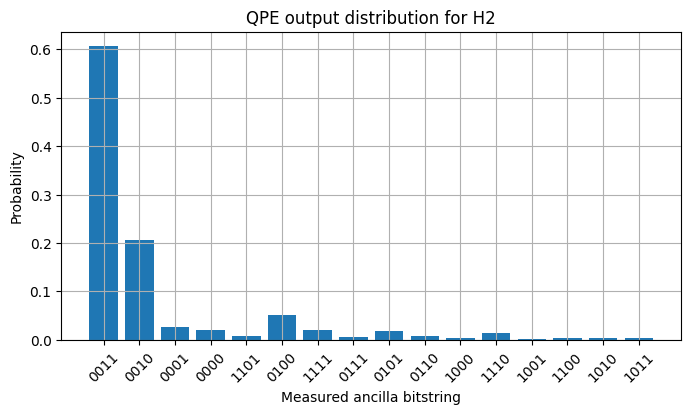

In [12]:
bitstrings = list(probs.keys())
values = np.asarray([float(probs[k]) for k in bitstrings], dtype=float)

plt.figure(figsize=(8, 4))
plt.bar(bitstrings, values)
plt.xlabel("Measured ancilla bitstring")
plt.ylabel("Probability")
plt.title("QPE output distribution for H2")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## Interpretation

The peak of the returned distribution indicates the most likely measured phase.

The quality of the estimate depends on:

- the overlap of the input state with a target eigenstate
- the number of ancilla qubits
- the choice of evolution time
- Trotterization accuracy

In this example, the Hartree-Fock state provides a practical approximate input
state for the ground-state calculation.

## QPE and VQE

It is useful to compare the conceptual role of QPE with VQE:

- **VQE** searches variationally for a low-energy state
- **QPE** extracts phase information from controlled time evolution

Both use the same Hamiltonian in this repository, so comparisons across
methods are physically consistent.

## What this notebook showed

We:

- built the shared `H2` Hamiltonian
- ran a minimal QPE workflow
- inspected the returned phase and probability distribution
- compared the energy estimate with the exact ground-state reference

This is the basic non-variational workflow in the repository.

## Next steps

Good follow-ups are:

- vary the number of ancillas
- vary the evolution time and Trotter depth
- compare QPE and VQE on the same molecule